You are given a directed, weighted graph with n nodes labeled from 0 to n - 1, and an array edges where edges[i] = [ui, vi, wi] represents a directed edge from node ui to node vi with cost wi.

Each node ui has a switch that can be used at most once: when you arrive at ui and have not yet used its switch, you may activate it on one of its incoming edges vi → ui reverse that edge to ui → vi and immediately traverse it.

The reversal is only valid for that single move, and using a reversed edge costs 2 * wi.

Return the minimum total cost to travel from node 0 to node n - 1. If it is not possible, return -1.

 

Example 1:

Input: n = 4, edges = [[0,1,3],[3,1,1],[2,3,4],[0,2,2]]

Output: 5

Explanation:

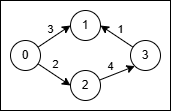

    Use the path 0 → 1 (cost 3).
    At node 1 reverse the original edge 3 → 1 into 1 → 3 and traverse it at cost 2 * 1 = 2.
    Total cost is 3 + 2 = 5.

Example 2:

Input: n = 4, edges = [[0,2,1],[2,1,1],[1,3,1],[2,3,3]]

Output: 3

Explanation:

    No reversal is needed. Take the path 0 → 2 (cost 1), then 2 → 1 (cost 1), then 1 → 3 (cost 1).
    Total cost is 1 + 1 + 1 = 3.

 

Constraints:

    2 <= n <= 5 * 104
    1 <= edges.length <= 105
    edges[i] = [ui, vi, wi]
    0 <= ui, vi <= n - 1
    1 <= wi <= 1000

 

In [ ]:
class Solution:
    def minCost(self, n: int, edges: List[List[int]]) -> int:
        g = [[] for _ in range(n)]
        for u, v, w in edges:
            g[u].append((v, w))
            g[v].append((u, 2 * w))
        
        dist = [inf] * n
        visited = [False] * n
        dist[0] = 0
        heap = [(0, 0)]  # (Distance, Node)

        while heap:
            cur_dist, x = heapq.heappop(heap)
            if x == n - 1:
                return cur_dist
            if visited[x]:
                continue
            visited[x] = True
            for y, w in g[x]:
                new_dist = cur_dist + w
                if new_dist < dist[y]:
                    dist[y] = new_dist
                    heapq.heappush(heap, (new_dist, y))

        return -1